/tmp/ipykernel_1103463/2634725767.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_figure['A'] = df_figure['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
/tmp/ipykernel_1103463/2634725767.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_figure['B'] = df_figure['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})


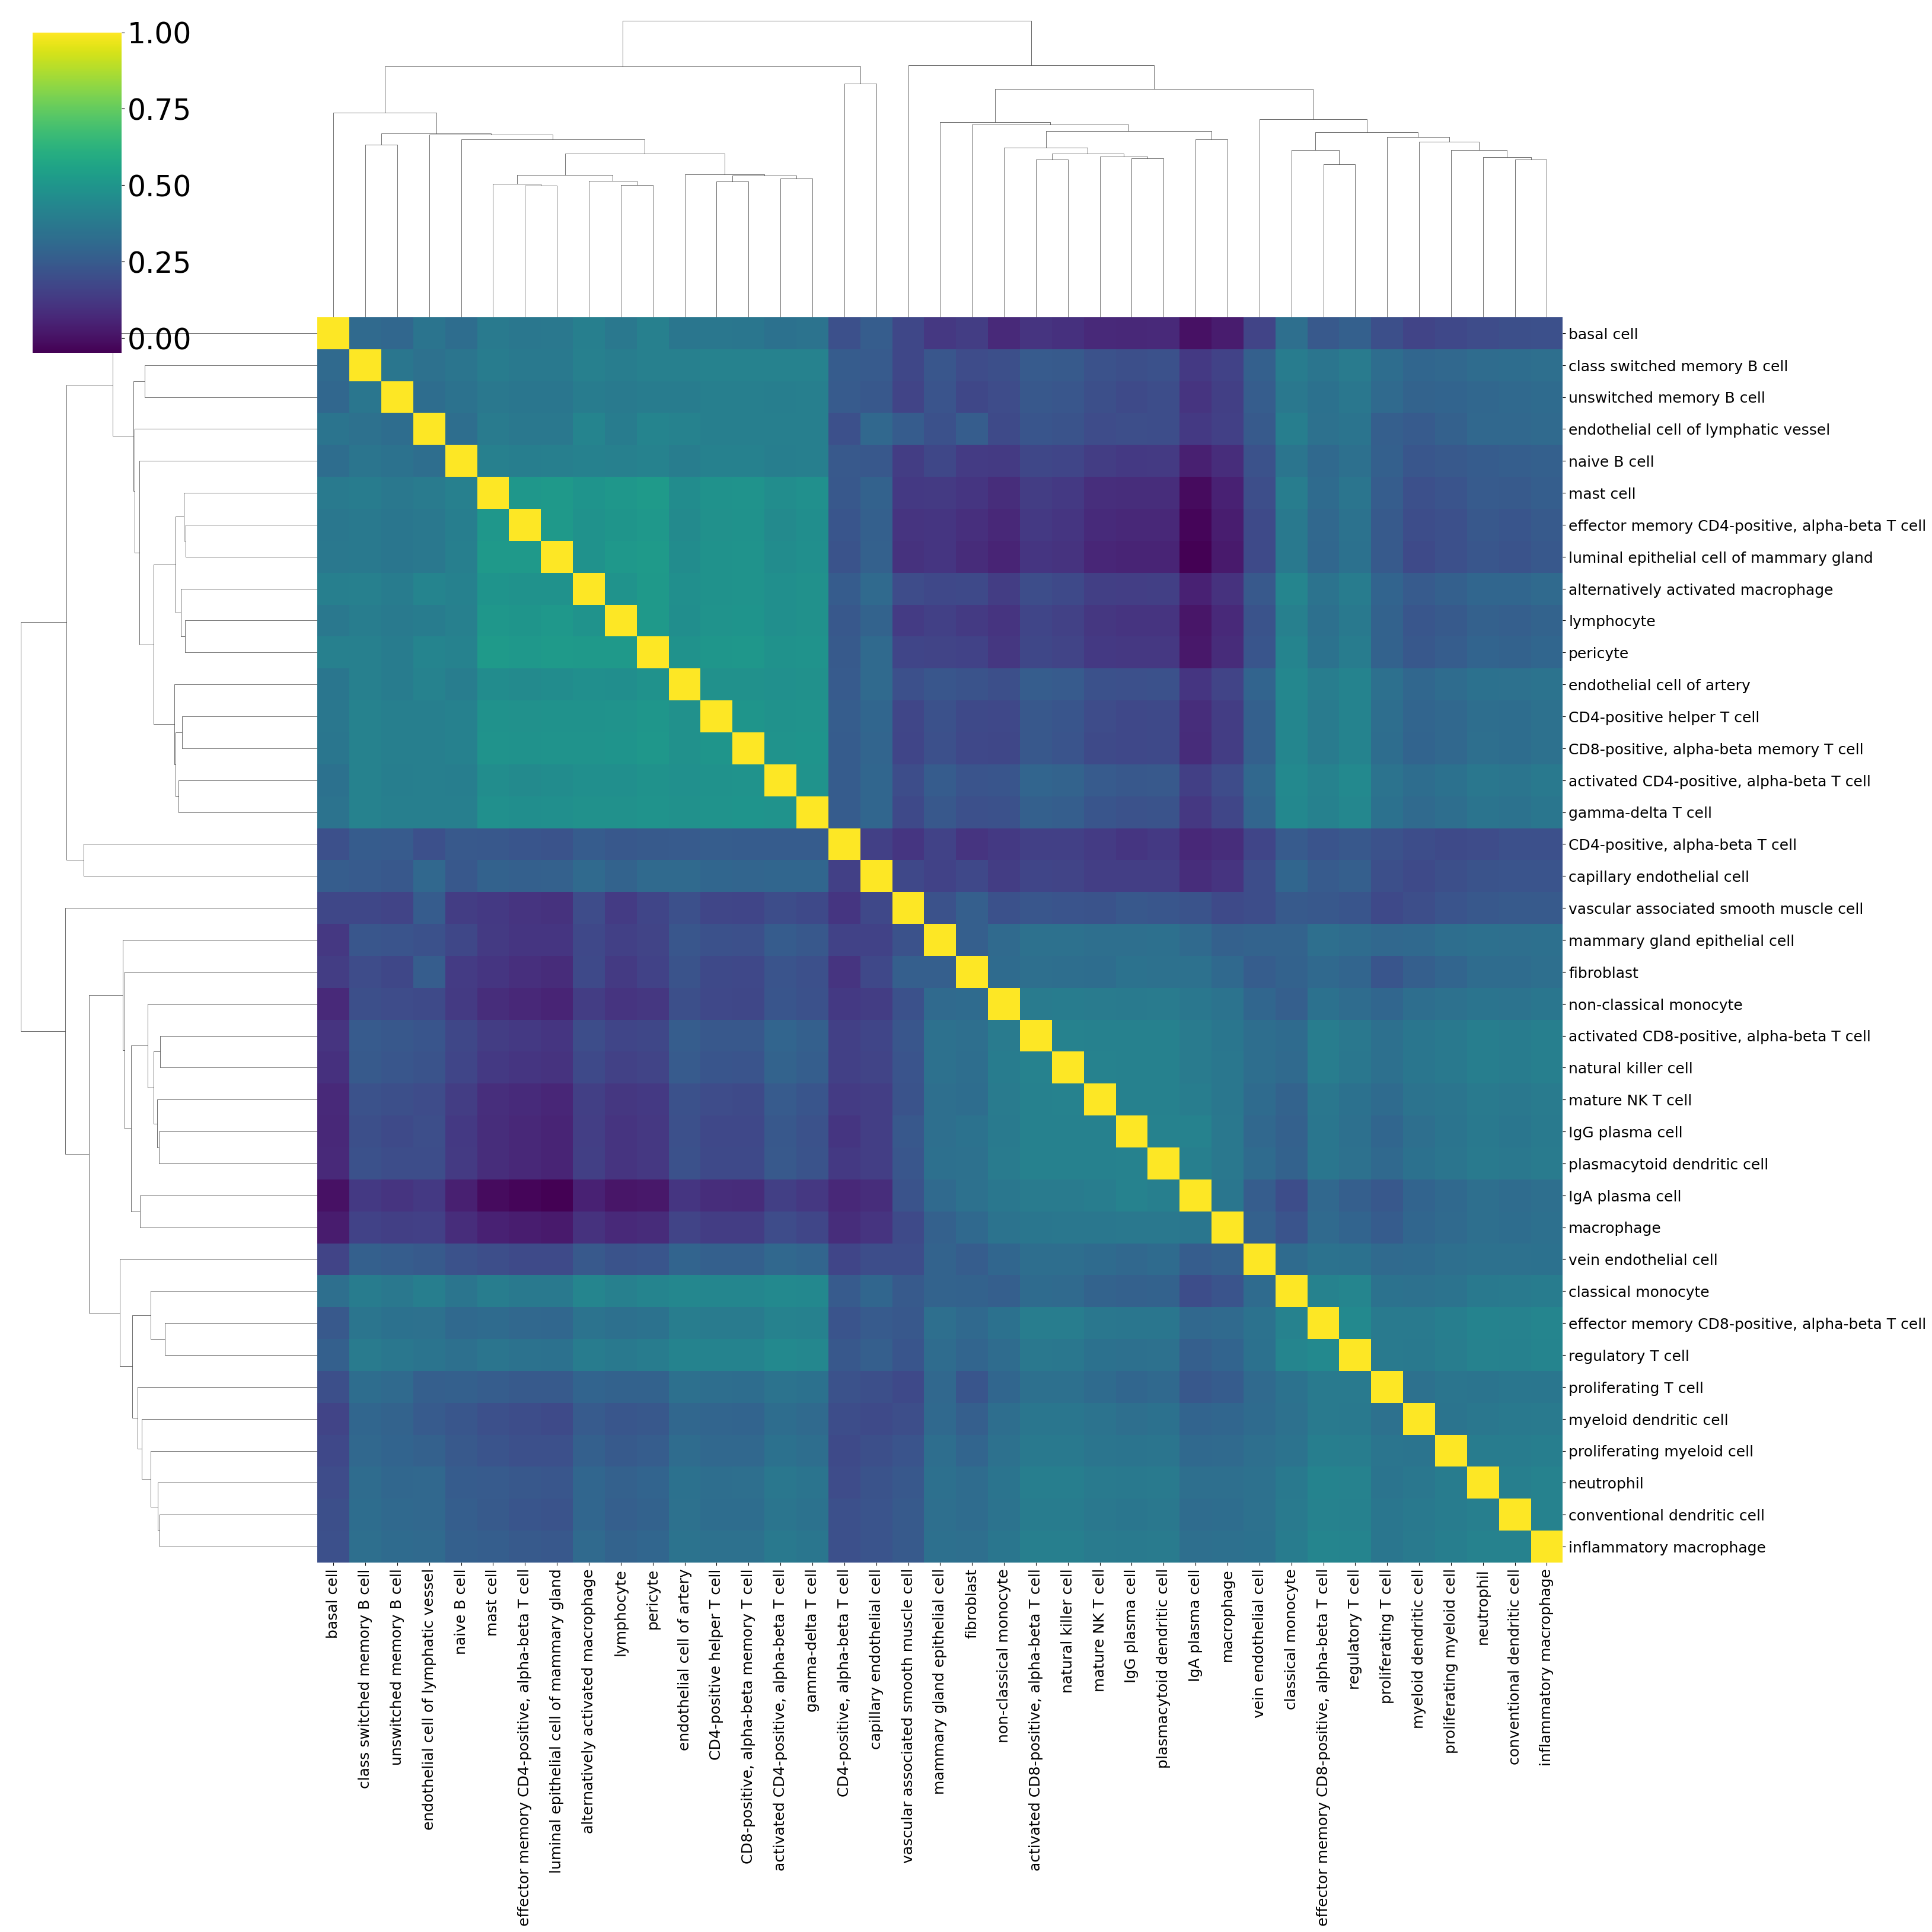

/tmp/ipykernel_1103463/2634725767.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_figure['A'] = df_figure['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
/tmp/ipykernel_1103463/2634725767.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_figure['B'] = df_figure['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})


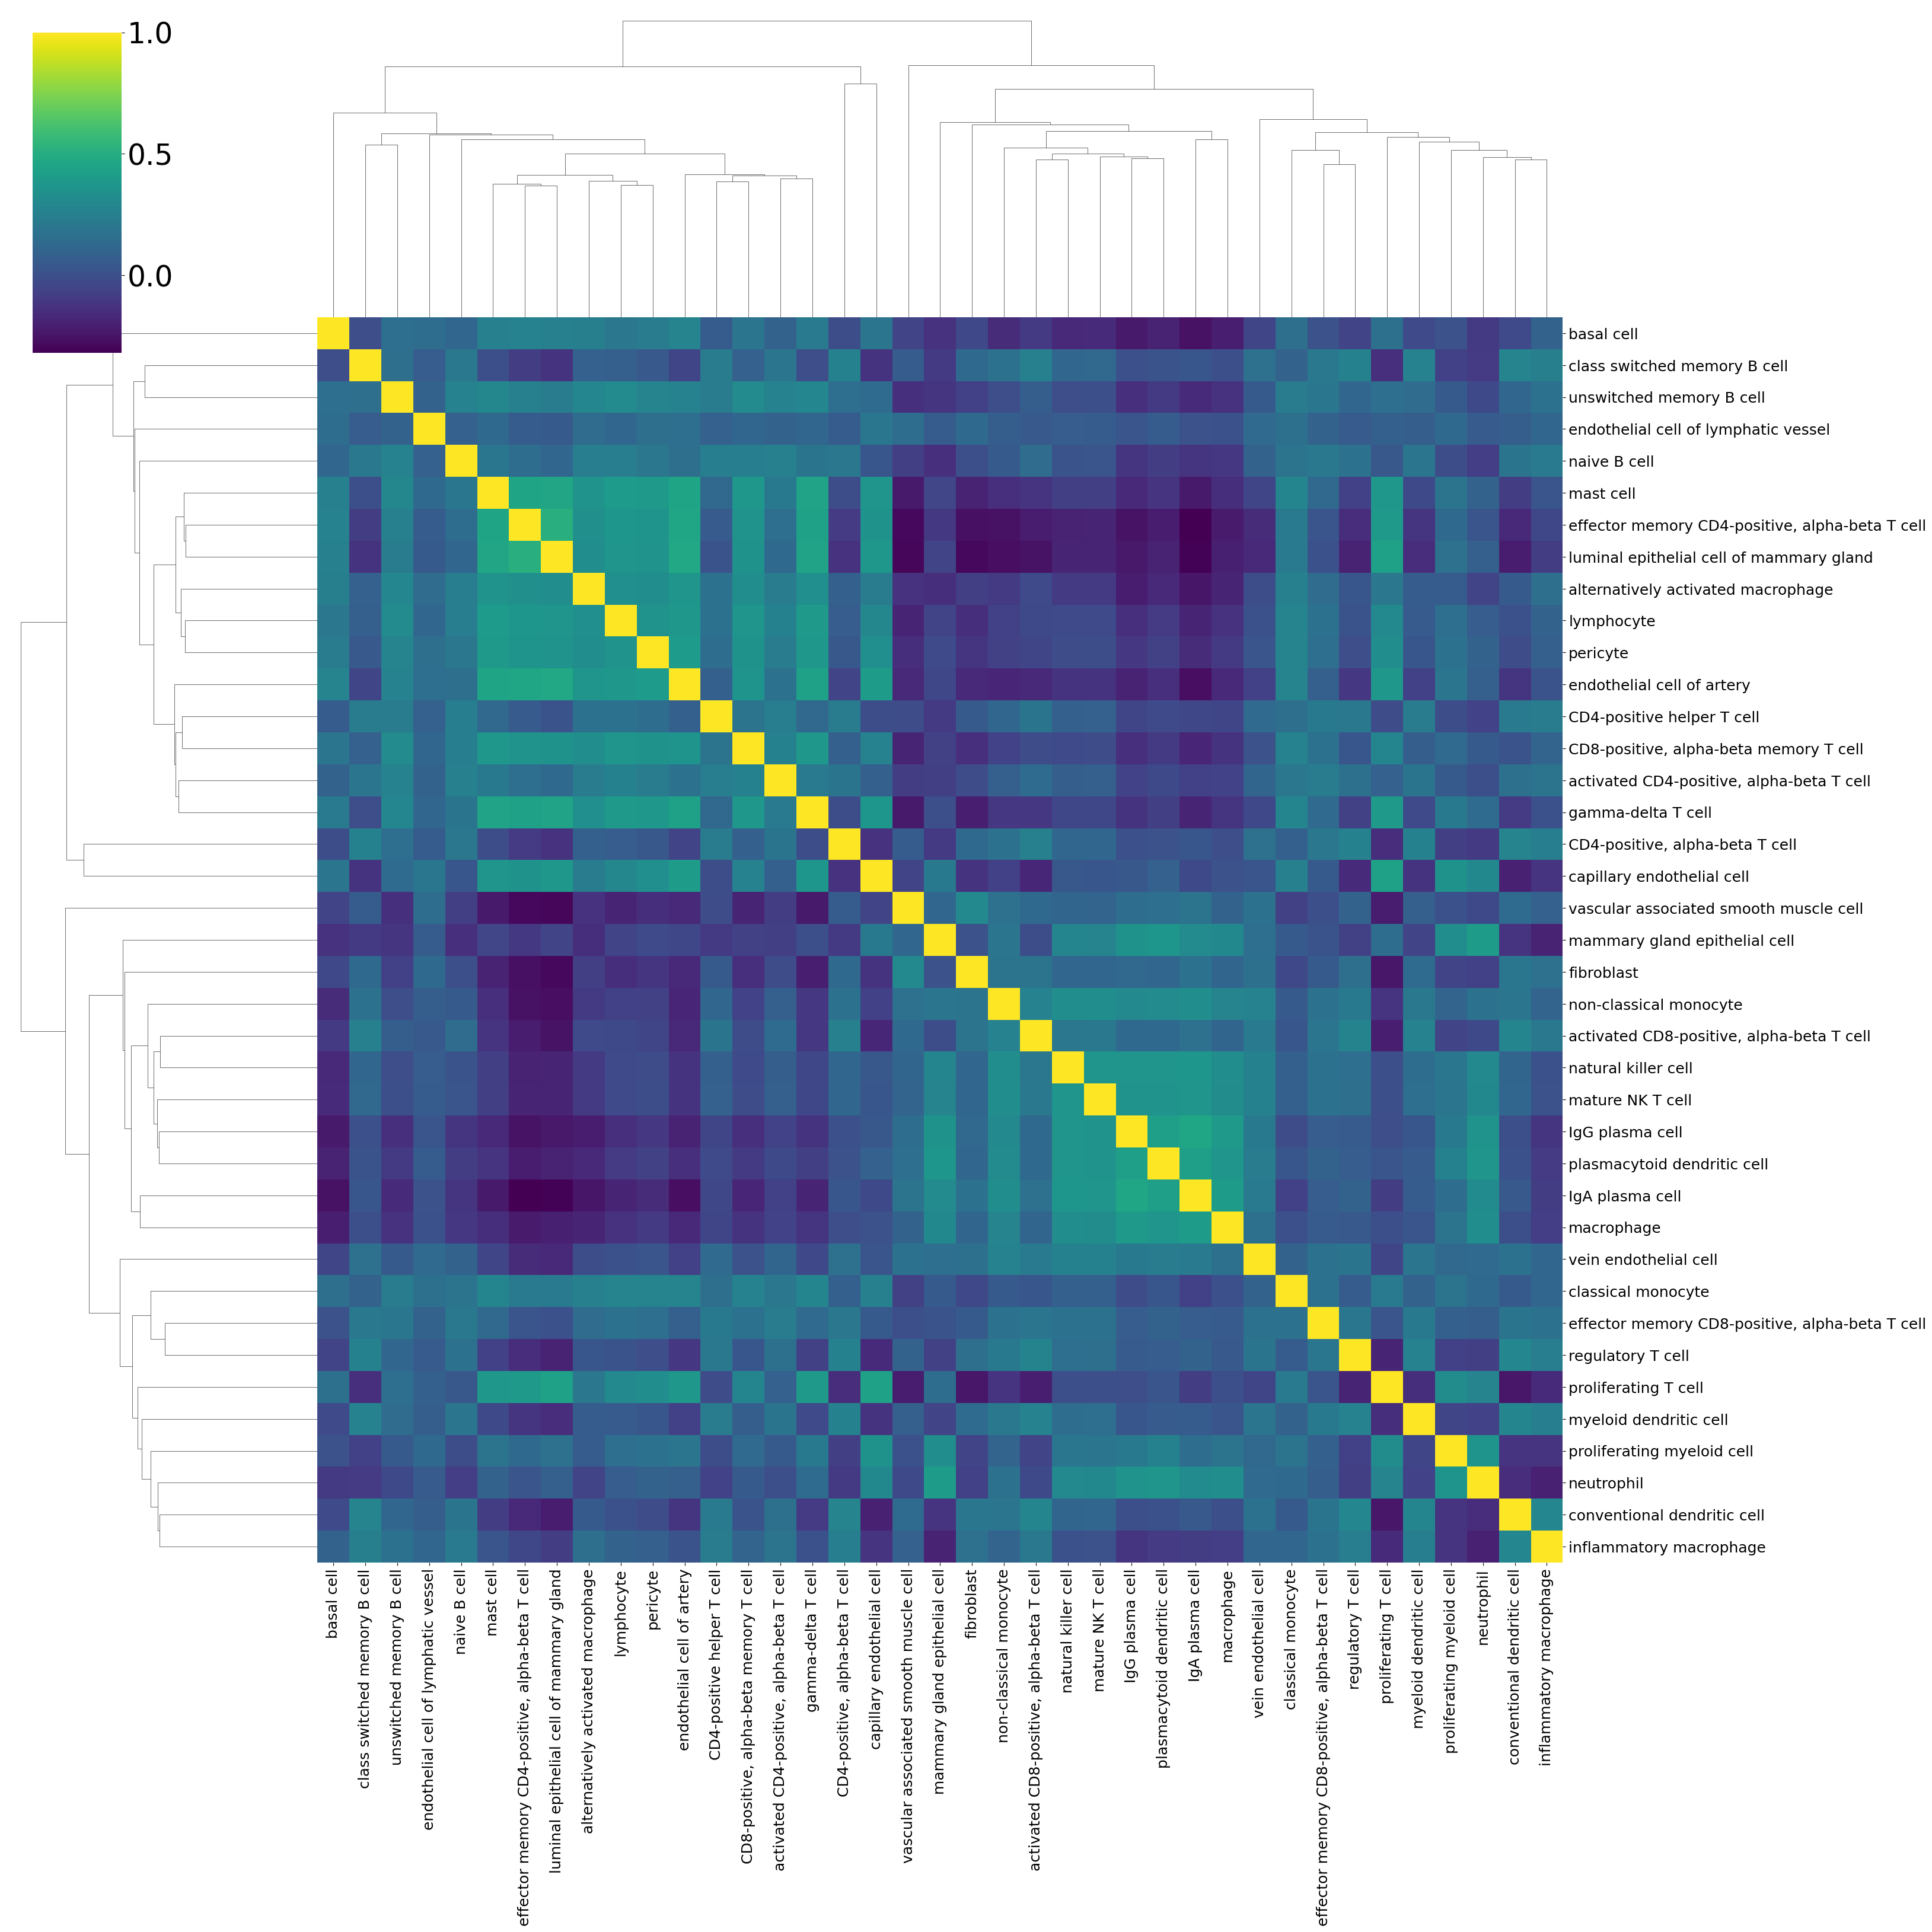

/tmp/ipykernel_1103463/2634725767.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_figure['A'] = df_figure['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
/tmp/ipykernel_1103463/2634725767.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_figure['B'] = df_figure['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})


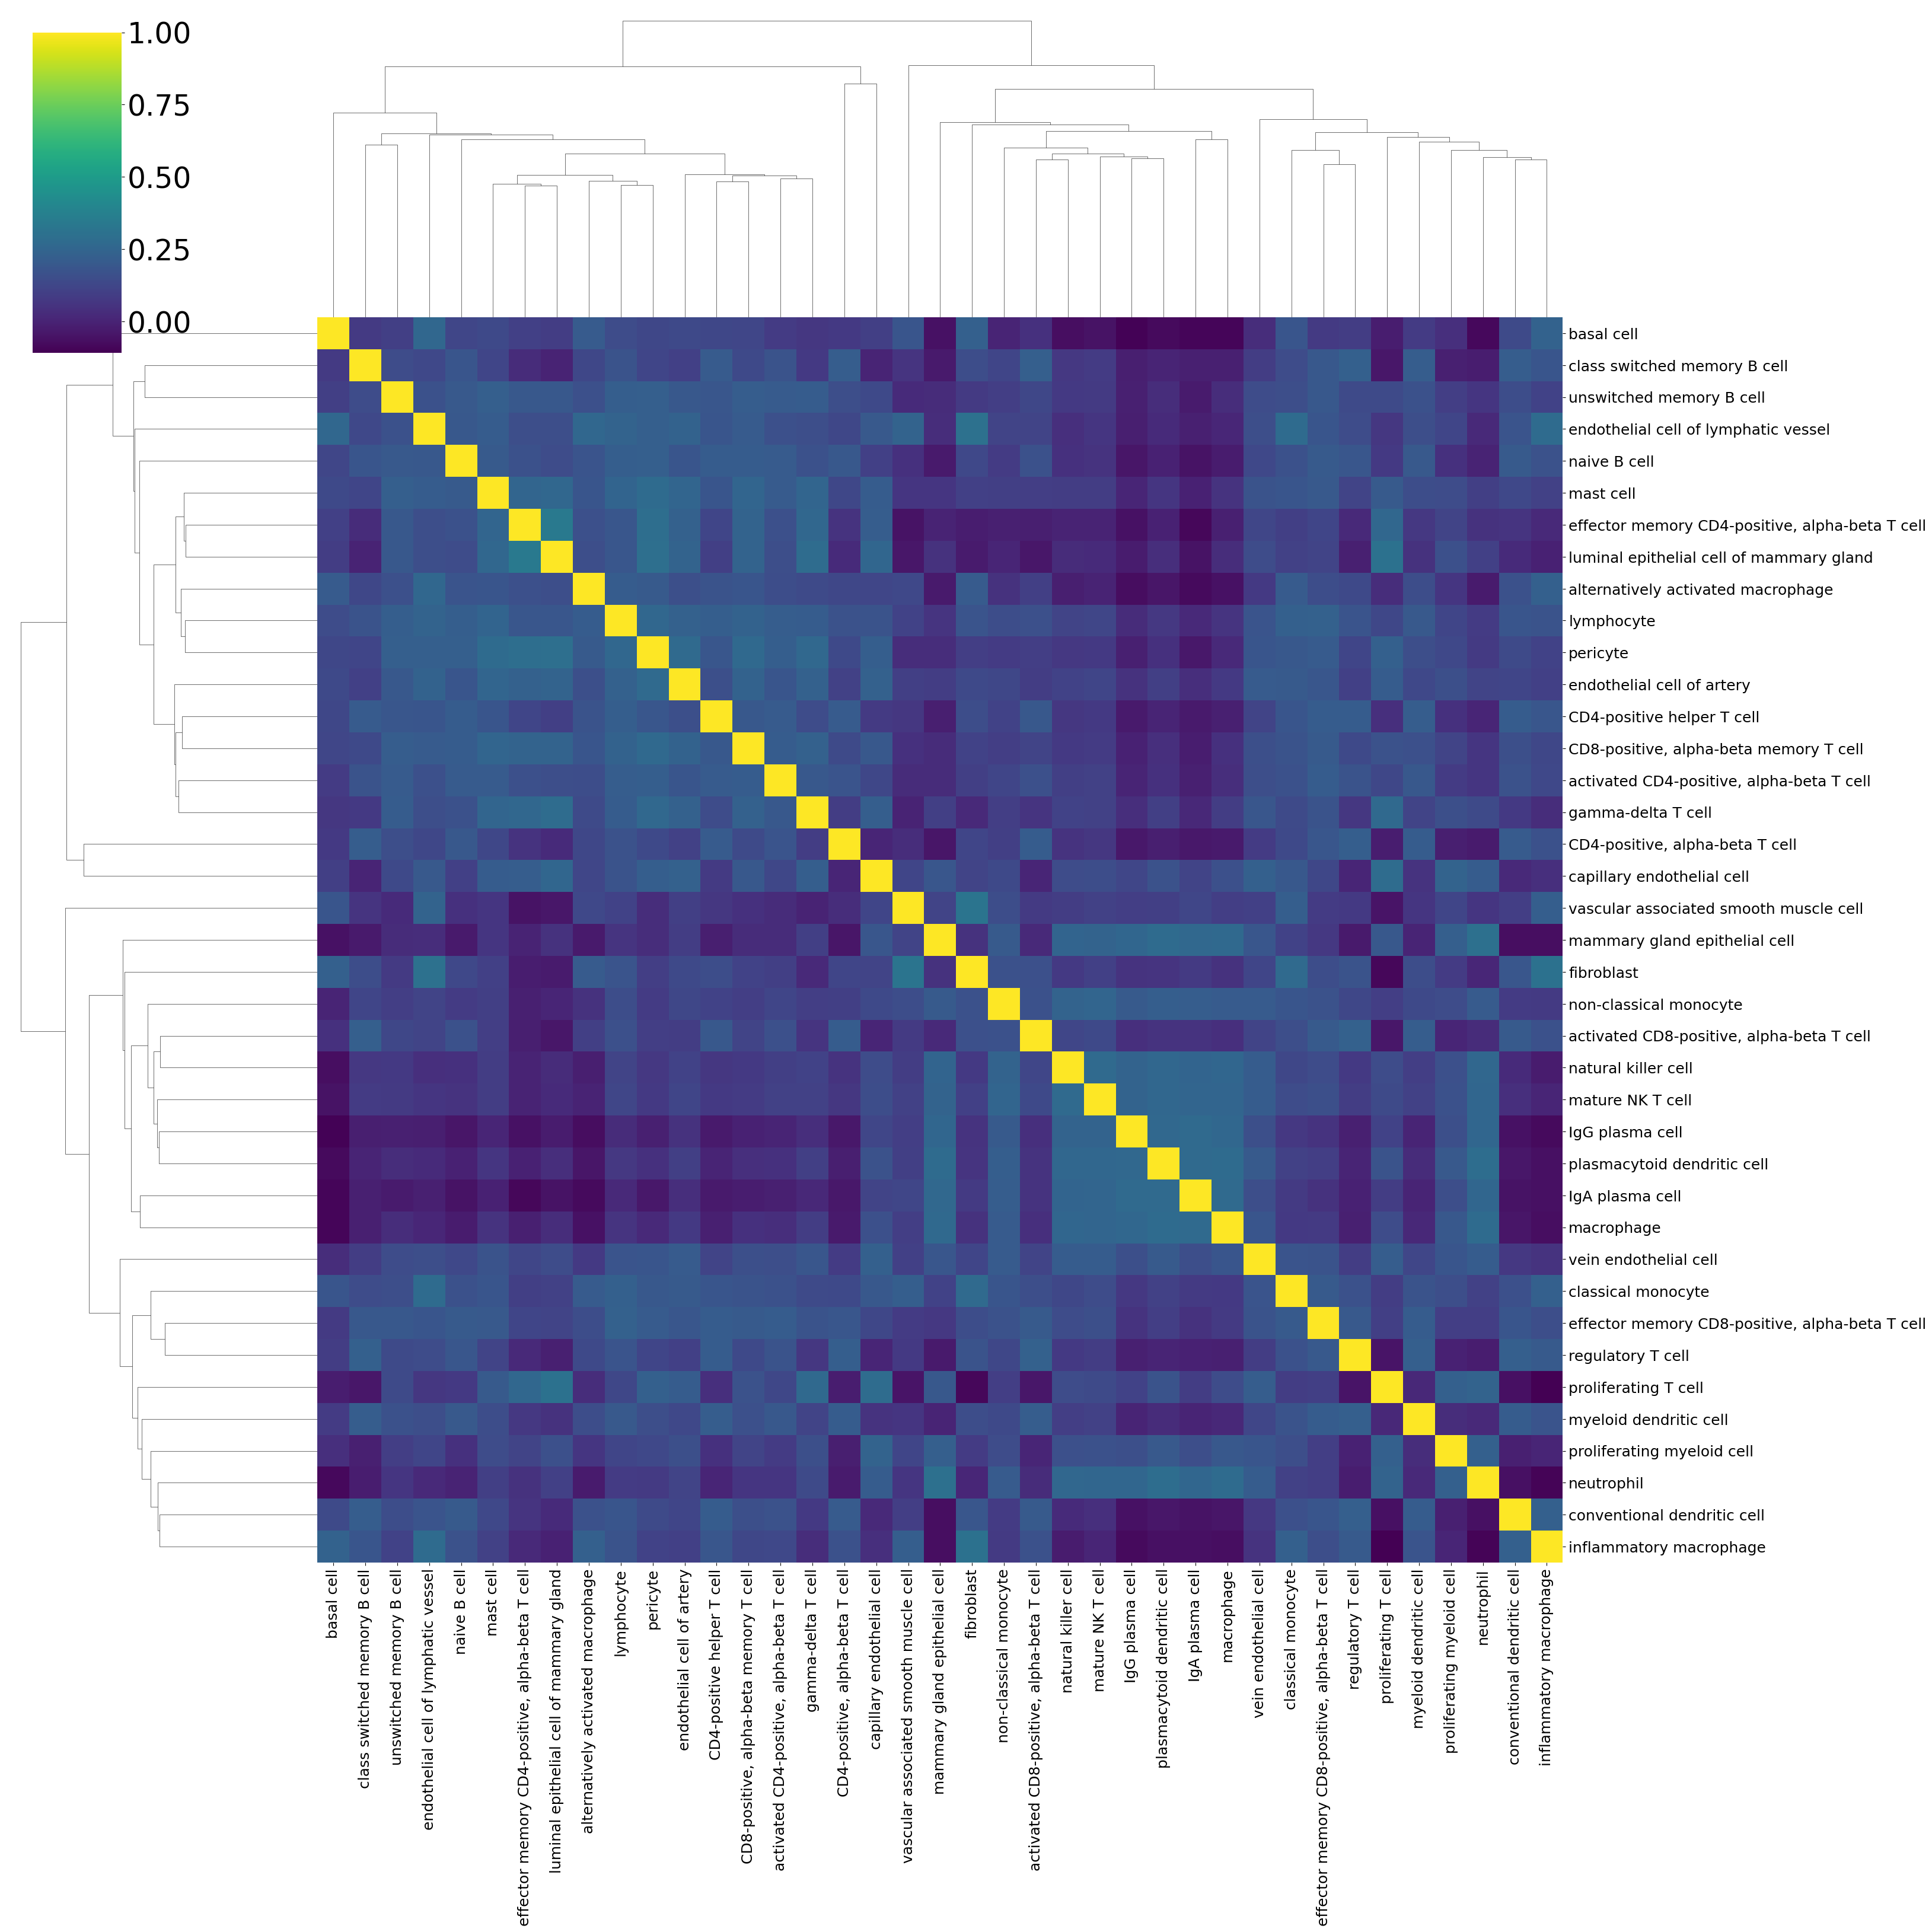

In [5]:
from tkinter import font
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

case = "23567"
slide = "23567_E1"

df_label = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case, slide, "MoranR_Cell2location.csv"), index_col=0)
df_figure = df_label[['A', 'B', 'R_val']]

df_figure['A'] = df_figure['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
df_figure['B'] = df_figure['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})

correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iat[38, 38] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(30, 30), cmap="viridis")
cax = cell2location_cluster.ax_cbar
cax.tick_params(labelsize=35)
row_linkage = cell2location_cluster.dendrogram_row.linkage
col_linkage = cell2location_cluster.dendrogram_col.linkage
# 获取热图轴并调整x轴和y轴字体大小
heatmap_ax = cell2location_cluster.ax_heatmap
heatmap_ax.tick_params(axis='x', labelsize=18)  # 调整x轴字体大小
heatmap_ax.tick_params(axis='y', labelsize=18)  # 调整y轴字体大小
plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source/selected_figures", case+"_"+slide+"_"+"cell2location_cluster_viridis.pdf"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

df_label = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case, slide, "MoranR_Hist2Cell.csv"), index_col=0)
df_figure = df_label[['A', 'B', 'R_val']]

df_figure['A'] = df_figure['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
df_figure['B'] = df_figure['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})

correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iat[38, 38] = 1.0
hist2cell_cluster = sns.clustermap(correlation_df, figsize=(30, 30), row_linkage=row_linkage, col_linkage=col_linkage, cmap="viridis")
cax = hist2cell_cluster.ax_cbar
cax.tick_params(labelsize=35)
# 获取热图轴并调整x轴和y轴字体大小
heatmap_ax = hist2cell_cluster.ax_heatmap
heatmap_ax.tick_params(axis='x', labelsize=18)  # 调整x轴字体大小
heatmap_ax.tick_params(axis='y', labelsize=18)  # 调整y轴字体大小
plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source/selected_figures", case+"_"+slide+"_"+"hist2cell_cluster_viridis.pdf"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

df_label = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case, slide, "MoranR_STNet.csv"), index_col=0)
df_figure = df_label[['A', 'B', 'R_val']]


df_figure['A'] = df_figure['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
df_figure['B'] = df_figure['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})

correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iat[38, 38] = 1.0
stnet_cluster = sns.clustermap(correlation_df, figsize=(30, 30), row_linkage=row_linkage, col_linkage=col_linkage, cmap="viridis")
cax = stnet_cluster.ax_cbar
cax.tick_params(labelsize=35)
# 获取热图轴并调整x轴和y轴字体大小
heatmap_ax = stnet_cluster.ax_heatmap
heatmap_ax.tick_params(axis='x', labelsize=18)  # 调整x轴字体大小
heatmap_ax.tick_params(axis='y', labelsize=18)  # 调整y轴字体大小
plt.savefig(os.path.join("//data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source/selected_figures", case+"_"+slide+"_"+"stnet_cluster_viridis.pdf"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [1]:
from tkinter import font
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

df_label = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case, slide, "MoranR_Cell2location.csv"), index_col=0)
df_figure = df_label[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iat[38, 38] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(30, 30), row_linkage=row_linkage, col_linkage=col_linkage, cmap="viridis", 
                                       xticklabels=False, yticklabels=False)
cax = cell2location_cluster.ax_cbar
cax.tick_params(labelsize=35)
row_linkage = cell2location_cluster.dendrogram_row.linkage
col_linkage = cell2location_cluster.dendrogram_col.linkage
plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source/selected_figures", case+"_"+slide+"_"+"cell2location_cluster_viridis_no_annotation.svg"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

df_label = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case, slide, "MoranR_Hist2Cell.csv"), index_col=0)
df_figure = df_label[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iat[38, 38] = 1.0
hist2cell_cluster = sns.clustermap(correlation_df, figsize=(30, 30), row_linkage=row_linkage, col_linkage=col_linkage, cmap="viridis", 
                                   xticklabels=False, yticklabels=False)
cax = hist2cell_cluster.ax_cbar
cax.tick_params(labelsize=35)
plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source/selected_figures", case+"_"+slide+"_"+"hist2cell_cluster_viridis_no_annotation.svg"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

df_label = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source", case, slide, "MoranR_STNet.csv"), index_col=0)
df_figure = df_label[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iat[38, 38] = 1.0
stnet_cluster = sns.clustermap(correlation_df, figsize=(30, 30), row_linkage=row_linkage, col_linkage=col_linkage, cmap="viridis", 
                               xticklabels=False, yticklabels=False)
cax = stnet_cluster.ax_cbar
cax.tick_params(labelsize=35)
plt.savefig(os.path.join("//data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/cross_source/selected_figures", case+"_"+slide+"_"+"stnet_cluster_viridis_no_annotation.svg"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

NameError: name 'case' is not defined